In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import numpy as np
import tqdm as notebook_tqdm

from sklearn.model_selection import train_test_split
from nltk.stem import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
#reading train data
train = pd.read_csv('train.csv', encoding="cp1252")
print(train.shape)
train.sample(5)

(31015, 9)


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
13735,5b65d15956,http://twitpic.com/676hv - R.I.P Fristy just t...,negative,noon,21-30,Venezuela,28435940,882050.0,32
14637,5ecb8e7d02,"In case no one gave you a heads up, AT&T just...",positive,morning,46-60,United States of America,331002651,9147420.0,36
12675,7a053b3829,Wow that is a scary statistic,negative,morning,46-60,China,1439323776,9388211.0,153
29985,93c0d86282,But he`s so adorable.,positive,night,70-100,Namibia,2540905,823000.0,3
26363,80f58d14c9,i quite like God Save Our King too,positive,night,70-100,Equatorial Guinea,1402985,28050.0,50


In [3]:
#train description
train.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,3.101500e+04,3.101500e+04,31015.000000
mean,4.009768e+07,6.633212e+05,356.684733
std,1.500845e+08,1.811039e+06,2008.450729
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [4]:
train.describe(include = ['string'])

,textID,text,sentiment,Time of Tweet,Age of User,Country
count,31015,31014,31015,31015,31015,31015
unique,31015,31014,3,3,6,195
top,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan
freq,1,1,12548,10339,5171,169


In [5]:
# data info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 31015 entries, 0 to 31014
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            31015 non-null  str    
 1   text              31014 non-null  str    
 2   sentiment         31015 non-null  str    
 3   Time of Tweet     31015 non-null  str    
 4   Age of User       31015 non-null  str    
 5   Country           31015 non-null  str    
 6   Population -2020  31015 non-null  int64  
 7   Land Area (Km²)   31015 non-null  float64
 8   Density (P/Km²)   31015 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 2.1 MB


# EDA

In [6]:
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative,noon,60-70,Angola,32866272,1246700.0,26


In [7]:
#checking null values
train.isnull().sum()

textID              0
text                1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [8]:
#exlcuding null values
train = train[~train.text.isnull()]

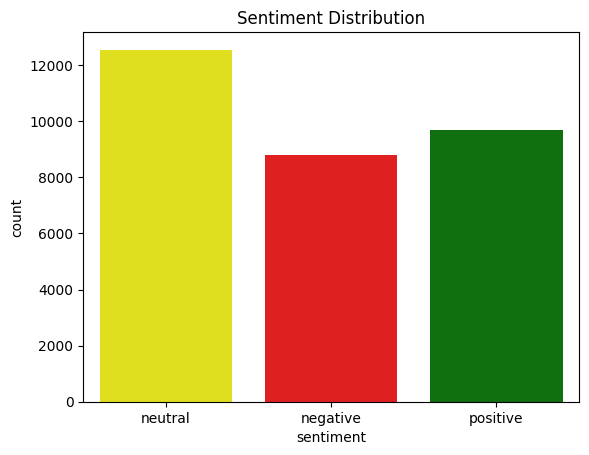

In [9]:
#sentiment values count
sns.countplot(data=train, x='sentiment', hue='sentiment', palette={'negative': 'red', 'positive': 'green','neutral':'yellow'}),
plt.title("Sentiment Distribution");

In [10]:
#average age according to type of sentiment
train['Age of User'].unique()

<StringArray>
['0-20', '21-30', '31-45', '46-60', '60-70', '70-100']
Length: 6, dtype: str

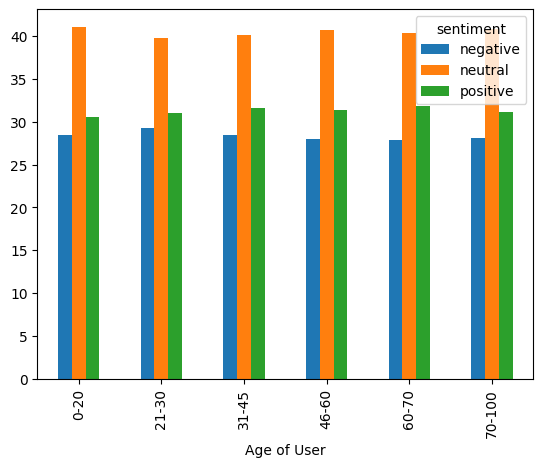

In [11]:
# average sentiment by age
((train.groupby(['Age of User','sentiment'])['sentiment'].value_counts())/train.groupby(['Age of User'])['Age of User'].value_counts() * 100).unstack().plot(kind = 'bar', stacked  = False);

# Feature Engineering

In [14]:
#getting polarity scores
sia  = SentimentIntensityAnalyzer()
train['polarity'] = train.text.apply(sia.polarity_scores).str['compound']

In [15]:
#for cleaning text feature
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"#\w+", "", text)     # remove hashtags
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\d+", "", text)      # remove numbers
    return text.strip()


In [16]:
train['cleaned_text'] = train.text.apply(clean_text)
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),polarity,cleaned_text
0,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,0.0000,id have responded if i were going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative,noon,21-30,Albania,2877797,27400.0,105,-0.7437,sooo sad i will miss you here in san diego
2,088c60f138,my boss is bullying me...,negative,night,31-45,Algeria,43851044,2381740.0,18,-0.5994,my boss is bullying me
3,9642c003ef,what interview! leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,-0.3595,what interview leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative,noon,60-70,Angola,32866272,1246700.0,26,0.0000,sons of why couldnt they put them on the rele...


In [17]:
# sentiment to numeric
train['sentiment'] = np.where(train['sentiment'] == 'positive', 2, np.where(train['sentiment'] == 'negative', 0, 1))
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),polarity,cleaned_text
0,cb774db0d1,"I`d have responded, if I were going",1,morning,0-20,Afghanistan,38928346,652860.0,60,0.0000,id have responded if i were going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,0,noon,21-30,Albania,2877797,27400.0,105,-0.7437,sooo sad i will miss you here in san diego
2,088c60f138,my boss is bullying me...,0,night,31-45,Algeria,43851044,2381740.0,18,-0.5994,my boss is bullying me
3,9642c003ef,what interview! leave me alone,0,morning,46-60,Andorra,77265,470.0,164,-0.3595,what interview leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",0,noon,60-70,Angola,32866272,1246700.0,26,0.0000,sons of why couldnt they put them on the rele...


In [18]:
# X and Y
x = train[['cleaned_text','polarity']]
y = train['sentiment']

In [20]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(24811, 2)
(6203, 2)
(24811,)
(6203,)


In [21]:
#vectorization of text
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
train_vec = vectorizer.fit_transform(x_train.cleaned_text).toarray()
test_vec = vectorizer.transform(x_test.cleaned_text).toarray()



In [22]:
#combining the bag of words with the polarity
X_train = np.hstack((train_vec,x_train.polarity.values.reshape(-1,1)))
X_test = np.hstack((test_vec,x_test.polarity.values.reshape(-1,1)))

In [23]:
#applying logistic regression
model = LogisticRegression(max_iter = 2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 0.7114299532484282
              precision    recall  f1-score   support

           0       0.73      0.64      0.68      1749
           1       0.65      0.73      0.69      2502
           2       0.78      0.75      0.77      1952

    accuracy                           0.71      6203
   macro avg       0.72      0.71      0.71      6203
weighted avg       0.72      0.71      0.71      6203



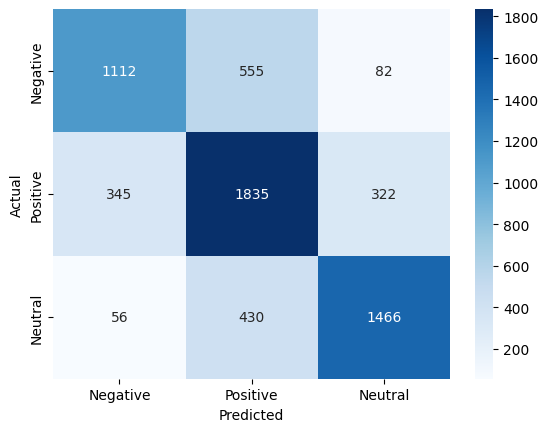

In [24]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative","Positive", 'Neutral'], yticklabels=["Negative","Positive",'Neutral'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [25]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Accuracy: 0.6862808318555538
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      1749
           1       0.64      0.68      0.66      2502
           2       0.76      0.73      0.75      1952

    accuracy                           0.69      6203
   macro avg       0.69      0.69      0.69      6203
weighted avg       0.69      0.69      0.69      6203



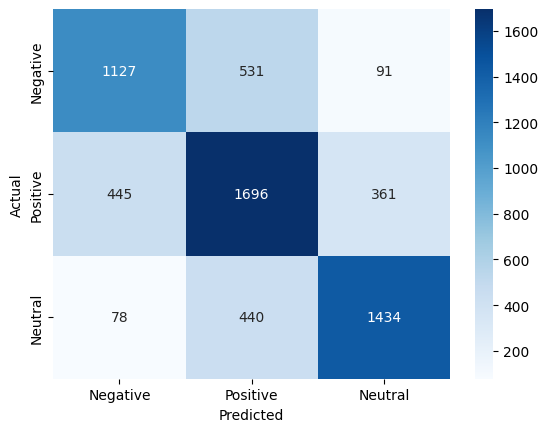

In [26]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative","Positive",'Neutral'], yticklabels=["Negative","Positive",'Neutral'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(objective="multi:softmax", num_class=3)
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Accuracy: 0.7115911655650492
              precision    recall  f1-score   support

           0       0.74      0.63      0.68      1749
           1       0.66      0.72      0.69      2502
           2       0.76      0.78      0.77      1952

    accuracy                           0.71      6203
   macro avg       0.72      0.71      0.71      6203
weighted avg       0.71      0.71      0.71      6203



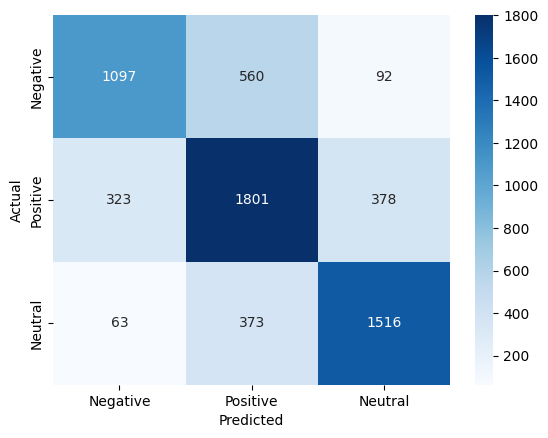

In [28]:
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative","Positive",'Neutral'], yticklabels=["Negative","Positive",'Neutral'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()